# Chapter 3.2: Project 1: Beach Data

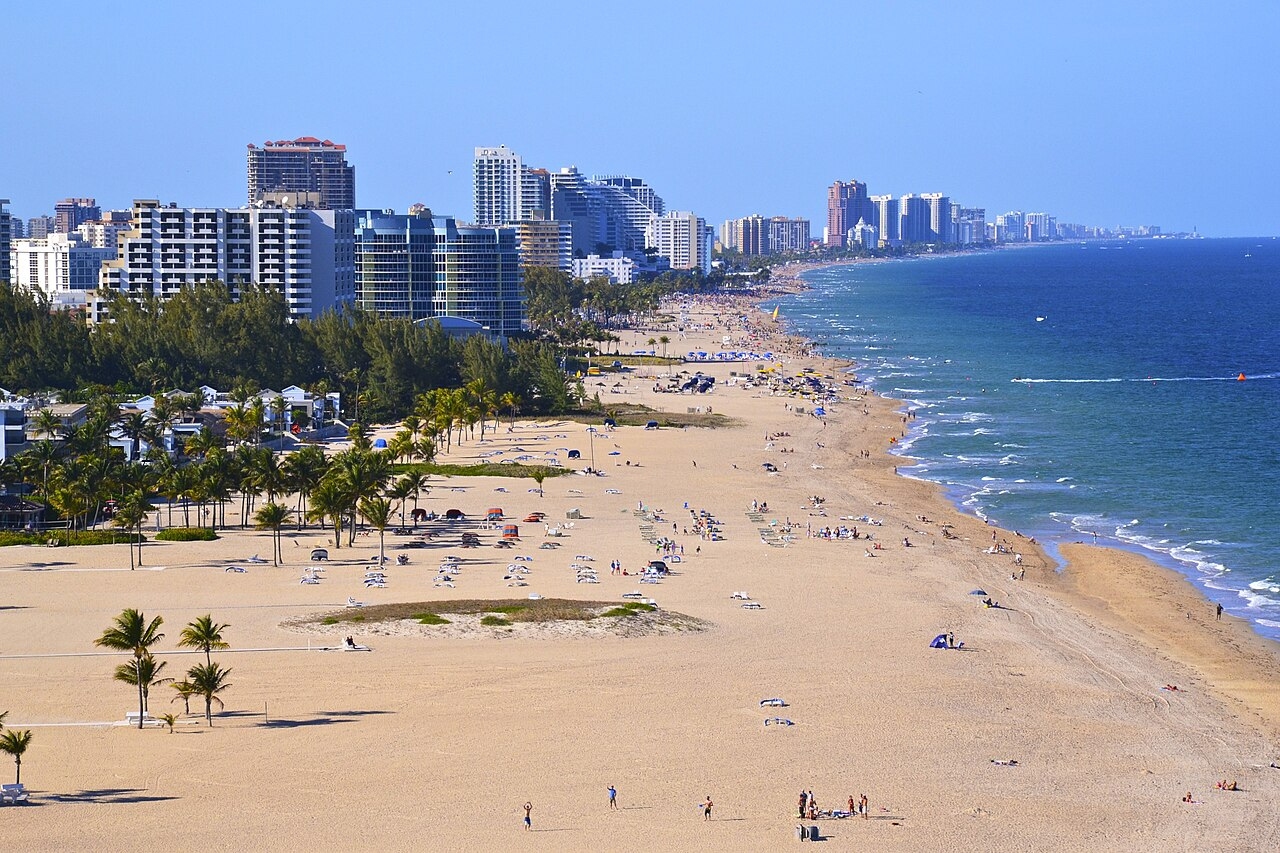
In this notebook, we will use beach data to practice two important ideas in data science:

1. **Summarizing data** with the mean, variance, and standard deviation
2. **Comparing groups** with a simple statistical test

This project is designed to build intuition first. We will start with a small demo before working with the full dataset, so you can see what the statistics mean before using them on real data.


# Part 1: Loading the data

The first thing we often do in a new project is load our data.

Before we jump into the full beach dataset, we will first look at a tiny example to understand why **spread** matters. Then we will return to the real data and apply the same ideas there.

In Google Colab, the common workflow is to mount Google Drive, check the working directory with `os.getcwd()`, and then read the CSV with pandas.

In [ ]:
# Install packages once if needed
# !pip install pandas matplotlib seaborn scipy

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
# Load OTU table
from google.colab import drive
drive.mount('/content/drive')


beach = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/scip_data/project1/beach_data.csv')

beach.head()

# Mini Demo: Mean, Variance, and Standard Deviation

Before using the beach data, let's practice with a tiny example.

Averages are helpful, but they do not tell the whole story. Two datasets can have the same mean and still look very different if one set is much more spread out than the other.

That spread is what **variance** and **standard deviation** measure.

- **Variance** = how spread out the data are, on average
- **Standard deviation** = the typical distance from the mean


In [ ]:
# Two small example datasets
low_spread = pd.Series([10, 11, 10, 9, 10])
high_spread = pd.Series([2, 8, 15, 1, 20])

# Calculate summary statistics
print("Low-spread dataset")
print("Mean:", low_spread.mean())
print("Variance:", low_spread.var())
print("Standard deviation:", low_spread.std())
print()

print("High-spread dataset")
print("Mean:", high_spread.mean())
print("Variance:", high_spread.var())
print("Standard deviation:", high_spread.std())

Low-spread dataset
Mean: 10.0
Variance: 0.5
Standard deviation: 0.7071067811865476

High-spread dataset
Mean: 9.2
Variance: 67.69999999999999
Standard deviation: 8.228000972289685


Notice that the two datasets may have similar averages, but the second one has much more variation.

This matters in data science because two groups can look similar at first glance, but one may be much less consistent than the other. Standard deviation helps us describe that difference clearly.

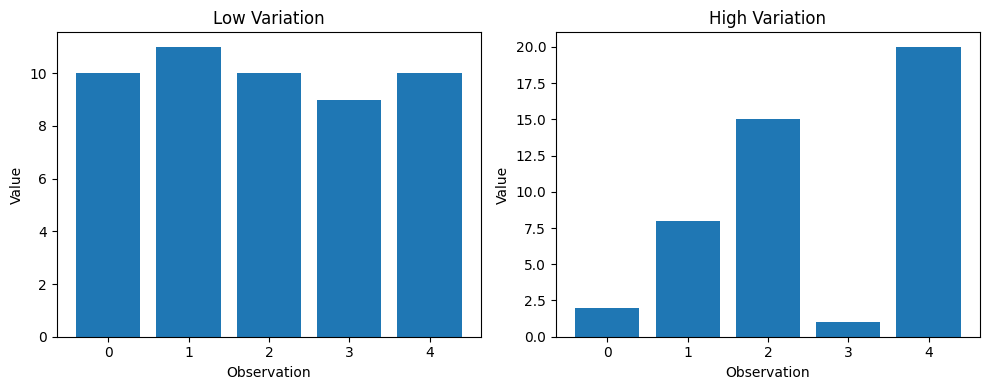

In [ ]:
# Visual demo: compare spread
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(range(len(low_spread)), low_spread)
axes[0].set_title("Low Variation")
axes[0].set_xlabel("Observation")
axes[0].set_ylabel("Value")

axes[1].bar(range(len(high_spread)), high_spread)
axes[1].set_title("High Variation")
axes[1].set_xlabel("Observation")
axes[1].set_ylabel("Value")

plt.tight_layout()
plt.show()

# Why do we care in data science?

Scientists and data analysts use standard deviation and variance to answer questions like:

- Are the measurements consistent?
- Are some groups more variable than others?
- Is an unusual value just random noise or something worth investigating?

Now that we have a sense of what spread means, we can apply the same idea to the beach dataset.

# Part 2: Practice with the beach data

We are ready to move from the toy example to the real dataset.

As you work through the questions below, remember to think about both:

- the **average** value
- the **spread** of the values


# Question 1: Standard Deviation of Weight

Use the `std()` function to calculate the standard deviation of the weight column.

Before you compute it, ask yourself:

- Are the weights tightly grouped or spread out?
- What does the standard deviation tell us about the consistency of the data?
- Why might a scientist care about that?

# Question 2: Bar Plot of Weight

Make a bar plot of the weight values.

A bar plot is a simple way to see whether the values are similar or different across observations.

# Question 3: Bar Plot with Sample Names

Add the sample names to the bar plot so it is easier to see which value belongs to which sample.

# Question 4: Bar Plot with a Different Color

Change the bar color to make the plot easier to read and compare.

# Part 3: Compare Weight Between Animals

Now we want to know whether the animals have different weights.

This is where statistics helps us answer a bigger question: are the differences we see likely real, or could they just be due to random variation?

A **p-value** helps us make that decision.

We want to know if there is a difference in weight between the animals. This requires stats. I was TERRIFIED of stats, and coding, as an undergrad. So take it from me that you do not need a ton of stats or code to run this comparison. We just need to remember one important value, and what it means.

That value is called a **p-value**. You've probably heard of this before.

A **p-value** is the probability of seeing a difference at least as large as the one we observed, **assuming there is actually no real difference between the groups**.

In other words, the p-value asks:

**If these animals are not actually different in weight, how surprising would our data be?**

The critical cutoff we will use is:

**p < 0.05**

This means there is less than a 5% chance of seeing a difference this large, or larger, if the animals are not actually different in weight.

So, our question is:

**Is there a difference in weight between the animals?**

If **p > 0.05**, then probably not. The difference in weight we observed is not surprising enough to rule out random variation. The animals might still be different, but our data do not give us strong enough evidence to say that.

If **p < 0.05**, then yes, probably. The difference we observed would be unlikely if the animals were actually the same in weight, so we say the groups are significantly different.

Put more simply:

A small p-value means, “This would be pretty surprising if there were no real difference.”

A large p-value means, “This could easily happen by chance, even if there were no real difference.”

In Python, the closest beginner-friendly equivalent is a one-way ANOVA with `scipy.stats.f_oneway()`.

ANOVA is a test that compares the averages of more than two groups at once. It helps us decide whether the differences between group means are larger than we would expect from random variation alone.

# Question 5: Is There a Difference in Weight Between the Animals?

Use the ANOVA test to compare the animal groups.

Then interpret the p-value:
- Is the result statistically significant?
- What does that mean for the animal groups?

#Part 4 - Bonus Question

The bonus question repeats the same analysis idea, but this time compares weight across tidal zones instead of animal groups.

This is a good chance to practice transferring the same statistical idea to a new question.